# JP Morgan Quant V4 — Two-Way Attention Transformer

## V3 → V4 核心改进

| 维度 | V3 | V4 |
|------|-----|-----|
| 数据组织 | 逐样本随机 batch | 逐日期，同一天所有股票打包 |
| Cross-Stock | batch mean + gate（假的） | Multi-head attention on (T, N, d)（真的） |
| Loss | Pairwise rank + MSE + IC | ListNet (listwise) + IC |
| 评估 | 单次 70/30 split | Rolling window (8 folds) |
| 股票数 | ~60 | ~230 |
| Validation | 无 | 每 fold 6 个月 val + early stopping |

<img src="./update_img/JP_Morgen_V4_Update.png">

## 0. 依赖 + 日志系统

In [2]:
import sys, os, io
from datetime import datetime
from matplotlib import pyplot as plt

MODEL_VERSION = "V4"
LOG_ROOT = "./log"

timestamp = datetime.now().strftime("%Y-%m-%d_%H%M")
RUN_NAME = f"{MODEL_VERSION}_{timestamp}"
RUN_DIR = os.path.join(LOG_ROOT, RUN_NAME)
LOG_FILE = os.path.join(RUN_DIR, "log.out")
ERR_FILE = os.path.join(RUN_DIR, "log.err")
IMG_DIR = os.path.join(RUN_DIR, "img")

os.makedirs(RUN_DIR, exist_ok=True)
os.makedirs(IMG_DIR, exist_ok=True)


class TeeWriter:
    def __init__(self, file_path, original_stream):
        self.file = open(file_path, 'a', buffering=1)
        self.original = original_stream
    def write(self, msg):
        self.original.write(msg)
        self.file.write(msg)
        self.file.flush()
    def flush(self):
        self.original.flush()
        self.file.flush()
    def close(self):
        self.file.close()
    @property
    def encoding(self):
        return getattr(self.original, 'encoding', 'utf-8')
    def isatty(self):
        return False


_notebook_stdout = sys.stdout
_notebook_stderr = sys.stderr
sys.stdout = TeeWriter(LOG_FILE, _notebook_stdout)
sys.stderr = TeeWriter(ERR_FILE, _notebook_stderr)


# ---- save_fig: 手动调用保存图片 ----
_img_counter = [0]

def save_fig(name=None):
    _img_counter[0] += 1
    fig = plt.gcf()
    if name is None:
        title = None
        if fig._suptitle:
            title = fig._suptitle.get_text()
        if not title:
            for ax in fig.axes:
                t = ax.get_title()
                if t:
                    title = t
                    break
        name = title or f'figure_{_img_counter[0]:02d}'
    safe = ''.join(c if c.isalnum() or c in (' ', '-', '_') else '_' for c in name)
    safe = safe.strip().replace(' ', '_')[:80]
    path = os.path.join(IMG_DIR, f'{_img_counter[0]:02d}_{safe}.png')
    fig.savefig(path, dpi=150, bbox_inches='tight')
    print(f'[LOG] Saved: {path}')


print(f"{'='*60}")
print(f"  Run:  {RUN_NAME}")
print(f"  Dir:  {RUN_DIR}/")
print(f"  Out:  log.out | Err: log.err | Img: img/")
print(f"{'='*60}\n")

  Run:  V4_2026-04-05_1902
  Dir:  ./log/V4_2026-04-05_1902/
  Out:  log.out | Err: log.err | Img: img/

Device: cuda
Stock universe: 228 tickers across 19 sectors
OK: local [2016-01-01 ~ 2025-12-31] covers [2018-01-01 ~ 2025-12-31]
Loaded 223 stocks [2018-01-01 ~ 2025-12-31]
Factors: 35
Removing 2 stocks with < 4 years
Keeping 221 stocks | 35 factors
Valid days: 1695 | 2018-03-29 ~ 2024-12-20
Dropped 0 stocks in normalization
Stocks with data: 221
Daily dataset: 1615 days | stocks/day: 193-221 (avg 211)
full_data ready | 1615 days | 35 factors
V4 params: 206,690
Loss: 70% ListNet + 30% IC
Data spans 6.4 years
12 folds
  Fold 1: Train [2018-07~2020-07] Val [2020-07~2020-11] Test [2020-11~2021-03] (504/86/81)
  Fold 2: Train [2018-07~2020-11] Val [2020-11~2021-03] Test [2021-03~2021-07] (590/81/85)
  Fold 3: Train [2018-07~2021-03] Val [2021-03~2021-07] Test [2021-07~2021-11] (671/85/86)
  Fold 4: Train [2018-07~2021-07] Val [2021-07~2021-11] Test [2021-11~2022-03] (756/86/82)
  Fold 5:

In [3]:
# !pip install yfinance

In [4]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
# import yfinance as yf
import matplotlib
matplotlib.use('Agg')  # 非交互后端，防止 Jupyter 隐式渲染
import matplotlib.pyplot as plt
from scipy import stats
from IPython.display import display, Image as IPImage
import os, pickle, copy
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# apple M4
# device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print(f'Device: {device}')

## 1. 数据下载

In [5]:
STOCK_UNIVERSE = {
    'mega_tech': ['AAPL','MSFT','GOOGL','AMZN','META','NVDA','TSLA','AVGO','ORCL','CRM','ADBE','AMD','INTC','CSCO','IBM'],
    'semicon': ['QCOM','TXN','MU','AMAT','LRCX','KLAC','MRVL','ON','ADI','SNPS','CDNS','NXPI','MCHP','SWKS','TER'],
    'cloud_saas': ['NOW','PANW','CRWD','NET','DDOG','ZS','SNOW','PLTR','FTNT','ANET','INTU','WDAY','TEAM','HUBS','VEEV','OKTA','MDB','BILL','ZI','ESTC'],
    'consumer_internet': ['NFLX','PYPL','SQ','SHOP','UBER','ABNB','SNAP','PINS','DASH','HOOD','APP','RBLX'],
    'energy_oil': ['XOM','CVX','COP','EOG','SLB','MPC','PSX','VLO','OXY','DVN','HES','HAL','BKR','FANG','KMI'],
    'energy_clean': ['FSLR','NEE','AES','CEG','VST','NRG','GEV','ENPH','DUK','SO'],
    'financials': ['JPM','GS','MS','BAC','WFC','C','SCHW','USB','PNC','BK','COF','AXP','BLK','BX','KKR','APO','ICE','CME','MCO','SPGI'],
    'insurance': ['CB','PGR','TRV','AON','ALL','MET'],
    'pharma_biotech': ['LLY','JNJ','UNH','ABBV','MRK','PFE','AMGN','GILD','BMY','REGN','VRTX','BIIB','MRNA','ILMN','SGEN','ALNY','INCY','BGNE','EXAS','PCVX'],
    'health_devices': ['ABT','TMO','ISRG','SYK','BSX','MDT','DHR','HCA','EW','DXCM','PODD','HOLX'],
    'emerging_biotech': ['CRSP','NTLA','BEAM','EDIT','RARE','TWST','RXRX','SDGR','TXG','NUVB'],
    'industrials': ['CAT','GE','RTX','HON','BA','LMT','GD','NOC','DE','ETN','PH','TT','LHX','TDG','HWM'],
    'consumer_staples': ['PG','KO','PEP','COST','WMT','MCD','SBUX','CL','MDLZ','MNST','PM','MO'],
    'consumer_disc': ['HD','LOW','TJX','ROST','NKE','MAR','HLT','RCL','GM','ORLY','BKNG','DIS'],
    'telecom': ['TMUS','VZ','T','CMCSA','WBD','CHTR'],
    'reits': ['PLD','AMT','EQIX','DLR','SPG','WELL','CCI','PSA'],
    'materials': ['LIN','SHW','ECL','APD','NEM','FCX'],
    'transport': ['UNP','CSX','NSC','FDX','UPS','WM'],
    'emerging_ai': ['PATH','AI','IONQ','SMCI','SOUN','BBAI','GFAI','AMBA'],
}

STOCK_UNIVERSE_FLAT = []
STOCK_SECTOR_MAP = {}
for sector, tickers in STOCK_UNIVERSE.items():
    for t in tickers:
        if t not in STOCK_UNIVERSE_FLAT:
            STOCK_UNIVERSE_FLAT.append(t)
            STOCK_SECTOR_MAP[t] = sector

print(f"Stock universe: {len(STOCK_UNIVERSE_FLAT)} tickers across {len(STOCK_UNIVERSE)} sectors")

In [6]:
MARKET_TICKERS = {'SPY':'SP500','QQQ':'Nasdaq100','XLE':'EnergySector','TLT':'Bond20Y','GLD':'Gold'}
START_DATE = '2018-01-01'
END_DATE   = '2025-12-31'
SAVE_DIR = './v3_data'
META_FILE = os.path.join(SAVE_DIR, 'meta.json')

import json

def save_meta(start, end, num_stocks):
    with open(META_FILE, 'w') as f:
        json.dump({'start_date': start, 'end_date': end, 'num_stocks': num_stocks, 'saved_at': pd.Timestamp.now().isoformat()}, f, indent=2)

def check_date_range(start, end):
    if not os.path.exists(META_FILE):
        return False, 'no meta.json'
    with open(META_FILE, 'r') as f:
        meta = json.load(f)
    if meta.get('start_date', '') > start:
        return False, f"local start {meta['start_date']} > {start}"
    if meta.get('end_date', '') < end:
        return False, f"local end {meta['end_date']} < {end}"
    print(f'OK: local [{meta["start_date"]} ~ {meta["end_date"]}] covers [{start} ~ {end}]')
    return True, 'OK'

def download_all(start=START_DATE, end=END_DATE):
    print(f'Downloading [{start} ~ {end}]...')
    raw = {}
    for t in STOCK_UNIVERSE_FLAT:
        try:
            df = yf.download(t, start=start, end=end, progress=False)
            if len(df) > 200: raw[t] = df; print(f'  + {t}: {len(df)}')
        except: print(f'  x {t}')
    mkt = {}
    for t, name in MARKET_TICKERS.items():
        try:
            df = yf.download(t, start=start, end=end, progress=False)
            if len(df) > 200: mkt[name] = df['Close'].values.flatten(); mkt[f'{name}_idx'] = df.index
        except: pass
    fund = {}
    for t in raw:
        try:
            info = yf.Ticker(t).info
            fund[t] = {k: info.get(v, np.nan) for k, v in [('pe','trailingPE'),('pb','priceToBook'),('market_cap','marketCap'),('dividend_yield','dividendYield'),('roe','returnOnEquity')]}
        except: fund[t] = {}
    return raw, mkt, fund

def save_data(raw, mkt, fund, start=START_DATE, end=END_DATE):
    os.makedirs(SAVE_DIR, exist_ok=True)
    for t, df in raw.items():
        df_save = df.copy()
        df_save.columns = [str(c).split(',')[0].strip().strip("('\"") for c in df_save.columns]
        df_save.to_csv(os.path.join(SAVE_DIR, f'{t}.csv'))
    with open(os.path.join(SAVE_DIR, 'market.pkl'), 'wb') as f: pickle.dump(mkt, f)
    with open(os.path.join(SAVE_DIR, 'fund.pkl'), 'wb') as f: pickle.dump(fund, f)
    save_meta(start, end, len(raw))
    print(f'Saved {len(raw)} stocks to {SAVE_DIR}/')

def load_data(start=START_DATE, end=END_DATE):
    raw = {}
    s_ts, e_ts = pd.Timestamp(start), pd.Timestamp(end)
    for fname in os.listdir(SAVE_DIR):
        if not fname.endswith('.csv'): continue
        t = fname.replace('.csv', '')
        df = pd.read_csv(os.path.join(SAVE_DIR, fname))
        if 'Date' in df.columns: df['Date'] = pd.to_datetime(df['Date']); df = df.set_index('Date')
        elif df.columns[0] in ('Unnamed: 0','date'): df.iloc[:,0] = pd.to_datetime(df.iloc[:,0]); df = df.set_index(df.columns[0])
        else: df.index = pd.to_datetime(df.index)
        df.columns = [str(c).split(',')[0].strip().strip("('\"") for c in df.columns]
        for col in df.columns: df[col] = pd.to_numeric(df[col], errors='coerce')
        df = df.dropna(how='all')
        df = df[(df.index >= s_ts) & (df.index <= e_ts)]
        if len(df) > 200: raw[t] = df
    with open(os.path.join(SAVE_DIR, 'market.pkl'), 'rb') as f: mkt = pickle.load(f)
    with open(os.path.join(SAVE_DIR, 'fund.pkl'), 'rb') as f: fund = pickle.load(f)
    for name in ['SP500','Nasdaq100','EnergySector','Bond20Y','Gold']:
        if name in mkt and f'{name}_idx' in mkt:
            idx = mkt[f'{name}_idx']; mask = (idx >= s_ts) & (idx <= e_ts)
            mkt[name] = mkt[name][mask]; mkt[f'{name}_idx'] = idx[mask]
    print(f'Loaded {len(raw)} stocks [{start} ~ {end}]')
    return raw, mkt, fund

data_valid = False
if os.path.exists(os.path.join(SAVE_DIR, 'market.pkl')):
    data_valid, reason = check_date_range(START_DATE, END_DATE)
    if not data_valid: print(f'Re-downloading: {reason}')
if data_valid:
    raw_data, market_data, fundamentals = load_data()
else:
    raw_data, market_data, fundamentals = download_all()
    save_data(raw_data, market_data, fundamentals)

## 2. 因子工程

In [7]:
def compute_v3_factors(df, market_data, fund_data=None):
    f = pd.DataFrame(index=df.index)
    c = pd.Series(df['Close'].values.flatten(), index=df.index)
    v = pd.Series(df['Volume'].values.flatten(), index=df.index)
    h = pd.Series(df['High'].values.flatten(), index=df.index)
    l = pd.Series(df['Low'].values.flatten(), index=df.index)
    o = pd.Series(df['Open'].values.flatten(), index=df.index)
    dr = c.pct_change()
    for n in [5,10,20,60]: f[f'ret_{n}d'] = c.pct_change(n)
    f['mom_accel'] = f['ret_5d'] - f['ret_5d'].shift(5)
    f['vol_20d'] = dr.rolling(20).std()
    f['vol_ratio'] = dr.rolling(5).std() / dr.rolling(20).std()
    f['vol_accel'] = f['vol_20d'].pct_change(5)
    f['intraday_vol'] = ((h - l) / c).rolling(20).mean()
    f['vol_spread'] = f['intraday_vol'] - f['vol_20d']
    f['vol_ma_ratio'] = v / v.rolling(20).mean()
    f['volume_trend'] = v.rolling(5).mean() / v.rolling(20).mean() - 1
    obv = (dr.apply(np.sign) * v).rolling(20).sum()
    f['obv_norm'] = obv / v.rolling(20).sum()
    vwap = (c * v).rolling(20).sum() / v.rolling(20).sum()
    f['vwap_dev'] = c / vwap - 1
    f['bb_pos'] = (c - c.rolling(20).mean()) / (c.rolling(20).std() * 2)
    f['ma_cross_s'] = c.rolling(5).mean() / c.rolling(20).mean() - 1
    f['ma_cross_l'] = c.rolling(20).mean() / c.rolling(60).mean() - 1
    delta = c.diff()
    gain = delta.where(delta > 0, 0).rolling(14).mean()
    loss_v = (-delta.where(delta < 0, 0)).rolling(14).mean()
    f['rsi'] = (100 - 100 / (1 + gain / loss_v.replace(0, np.nan))) / 100 - 0.5
    rmin, rmax = c.rolling(60).min(), c.rolling(60).max()
    f['price_pos'] = ((c - rmin) / (rmax - rmin).replace(0, np.nan)) - 0.5
    f['price_range'] = (h - l) / c
    for name in ['SP500','Nasdaq100','EnergySector']:
        if name in market_data:
            ref = pd.Series(market_data[name], index=market_data[f'{name}_idx'])
            ref_a = ref.reindex(df.index, method='ffill')
            f[f'rel_{name}'] = c.pct_change(20) - ref_a.pct_change(20)
            f[f'corr_{name}'] = dr.rolling(60).corr(ref_a.pct_change())
    f['ret_252d'] = c.pct_change(252)
    f['ma200_dev'] = c / c.rolling(200).mean() - 1
    f['sharpe_20d'] = f['ret_20d'] / f['vol_20d'].replace(0, np.nan)
    f['gap'] = (o / c.shift(1) - 1).rolling(5).mean()
    for k in ['pe','pb','market_cap','dividend_yield','roe']:
        val = fund_data.get(k, np.nan) if fund_data else np.nan
        f[f'f_{k}'] = val if (not np.isnan(val) if isinstance(val, float) else True) else 0.0
    f = f.ffill().dropna(subset=f.columns[:10])
    f = f.fillna(0.0)
    return f

sample = compute_v3_factors(raw_data[list(raw_data.keys())[0]], market_data, fundamentals.get(list(raw_data.keys())[0], {}))
print(f'Factors: {sample.shape[1]}')

## 3. 按天数据集（V4 核心改动）

<img src="./update_img/JP_Morgen_V4_rolling_window.png">

In [8]:
LOOKBACK = 20
SCALER_WINDOW = 80
MIN_HISTORY_YEARS = 4
MIN_STOCKS_RATIO = 0.80
MIN_STOCKS_PER_DAY = 20

In [9]:
all_stock = {}
for t, df in raw_data.items():
    fac = compute_v3_factors(df, market_data, fundamentals.get(t, {}))
    cs = pd.Series(df['Close'].values.flatten(), index=df.index)
    fut = cs.pct_change(5).shift(-5)
    idx = fac.index.intersection(fut.dropna().index)
    if len(idx) == 0: continue
    all_stock[t] = {'factors': fac.loc[idx], 'target': fut.loc[idx]}

cutoff = pd.Timestamp.now() - pd.DateOffset(years=MIN_HISTORY_YEARS)
short = [t for t in all_stock if all_stock[t]['factors'].index.min() > cutoff]
if short:
    print(f'Removing {len(short)} stocks with < {MIN_HISTORY_YEARS} years')
    for t in short: del all_stock[t]

NUM_FACTORS = list(all_stock.values())[0]['factors'].shape[1]
print(f'Keeping {len(all_stock)} stocks | {NUM_FACTORS} factors')

In [10]:
from collections import Counter

date_counts = Counter()
for d in all_stock.values():
    for dt in d['factors'].index: date_counts[dt] += 1

n_stocks = len(all_stock)
min_per_day = int(n_stocks * MIN_STOCKS_RATIO)
all_dates = sorted([dt for dt, cnt in date_counts.items() if cnt >= min_per_day])
print(f'Valid days: {len(all_dates)} | {all_dates[0].strftime("%Y-%m-%d")} ~ {all_dates[-1].strftime("%Y-%m-%d")}')

In [11]:
all_dates_set = set(all_dates)
stock_data = {}

for t, d in all_stock.items():
    fdf = d['factors']; tgt = d['target']; fn = fdf.values; dates_idx = fdf.index
    norm_rows = {}
    for i in range(max(SCALER_WINDOW, LOOKBACK), len(fn)):
        w = fn[max(0, i - SCALER_WINDOW):i]
        mu, sd = np.nanmean(w, axis=0), np.nanstd(w, axis=0)
        sd[sd < 1e-8] = 1.0
        s = (fn[i - LOOKBACK:i] - mu) / sd
        if s.shape != (LOOKBACK, NUM_FACTORS) or np.any(np.isnan(s)): continue
        dt = dates_idx[i]
        if dt in all_dates_set and not np.isnan(tgt.iloc[i]):
            norm_rows[dt] = {'x': s.astype(np.float32), 'y': tgt.iloc[i]}
    if len(norm_rows) > 0: stock_data[t] = norm_rows

tickers_list = sorted(stock_data.keys())
# log
dropped = [t for t in all_stock if t not in stock_data]
print(f"Dropped {len(dropped)} stocks in normalization")
if dropped:
    t = dropped[0]
    fdf = all_stock[t]['factors']
    print(f"  Example: {t} has {len(fdf)} rows, min_i = {max(SCALER_WINDOW, LOOKBACK)}")
    fn = fdf.values
    nan_count = 0
    for i in range(max(SCALER_WINDOW, LOOKBACK), len(fn)):
        w = fn[max(0, i - SCALER_WINDOW):i]
        mu, sd = np.nanmean(w, axis=0), np.nanstd(w, axis=0)
        sd[sd < 1e-8] = 1.0
        s = (fn[i - LOOKBACK:i] - mu) / sd
        if np.any(np.isnan(s)):
            nan_count += 1
    print(f"  Rows with NaN after norm: {nan_count}/{len(fn) - max(SCALER_WINDOW, LOOKBACK)}")
    # 哪些因子还有 NaN？
    print(f"  NaN per column in raw factors: {np.isnan(fn).sum(axis=0).tolist()}")
print(f'Stocks with data: {len(tickers_list)}')

daily_samples = {}
for dt in all_dates:
    dx, dy, dtk = [], [], []
    for t in tickers_list:
        if dt in stock_data[t]:
            dx.append(stock_data[t][dt]['x']); dy.append(stock_data[t][dt]['y']); dtk.append(t)
    if len(dx) >= MIN_STOCKS_PER_DAY:
        daily_samples[dt] = {'X': np.stack(dx), 'y': np.array(dy, dtype=np.float32), 'tickers': dtk}

valid_dates = sorted(daily_samples.keys())
n_per_day = [len(daily_samples[d]['tickers']) for d in valid_dates]
print(f'Daily dataset: {len(valid_dates)} days | stocks/day: {min(n_per_day)}-{max(n_per_day)} (avg {np.mean(n_per_day):.0f})')

In [12]:
full_data = {
    'daily_samples': daily_samples,
    'valid_dates': valid_dates,
    'tickers_list': tickers_list,
    'num_factors': NUM_FACTORS,
}

class DailyDataset(Dataset):
    def __init__(self, dates, daily_samples, max_stocks=None):
        self.dates = dates
        self.daily_samples = daily_samples
        self.max_stocks = max_stocks or max(len(daily_samples[dt]['tickers']) for dt in dates)
    def __len__(self): return len(self.dates)
    def __getitem__(self, idx):
        dt = self.dates[idx]; sample = self.daily_samples[dt]
        X = torch.FloatTensor(sample['X']); y = torch.FloatTensor(sample['y']); N = X.shape[0]
        if N < self.max_stocks:
            X = torch.cat([X, torch.zeros(self.max_stocks - N, X.shape[1], X.shape[2])])
            y = torch.cat([y, torch.zeros(self.max_stocks - N)])
        mask = torch.zeros(self.max_stocks); mask[:N] = 1.0
        return X, y, mask

print(f'full_data ready | {len(valid_dates)} days | {NUM_FACTORS} factors')

## 4. V4 Model — Two-Way Attention

In [13]:
class Time2Vec(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.lin = nn.Linear(1, 1); self.per = nn.Linear(1, d - 1)
    def forward(self, T, dev):
        t = (torch.arange(T, dtype=torch.float32, device=dev) / T).unsqueeze(-1)
        return torch.cat([self.lin(t), torch.sin(self.per(t))], dim=-1)

class TwoWayBlock(nn.Module):
    def __init__(self, d, nh, ff, drop):
        super().__init__()
        self.temporal = nn.TransformerEncoderLayer(d_model=d, nhead=nh, dim_feedforward=ff, dropout=drop, batch_first=True, norm_first=True)
        self.cross_sec = nn.TransformerEncoderLayer(d_model=d, nhead=nh, dim_feedforward=ff, dropout=drop, batch_first=True, norm_first=True)
    def forward(self, x, stock_mask=None):
        x = self.temporal(x)
        T = x.shape[1]
        x = x.permute(1, 0, 2)
        pad_mask = (stock_mask == 0).unsqueeze(0).expand(T, -1) if stock_mask is not None else None
        x = self.cross_sec(x, src_key_padding_mask=pad_mask)
        return x.permute(1, 0, 2)

class QuantV4(nn.Module):
    def __init__(self, nf, d=128, nh=4, nl=3, ff=256, drop=0.15):
        super().__init__()
        self.proj = nn.Sequential(nn.Linear(nf, d), nn.LayerNorm(d), nn.GELU(), nn.Dropout(drop))
        self.t2v = Time2Vec(d)
        self.blocks = nn.ModuleList([TwoWayBlock(d, nh, ff, drop) for _ in range(nl)])
        self.pool = nn.Sequential(nn.Linear(d, d // 4), nn.Tanh(), nn.Linear(d // 4, 1))
        self.head = nn.Sequential(nn.LayerNorm(d), nn.Linear(d, d // 2), nn.GELU(), nn.Dropout(drop), nn.Linear(d // 2, 1))
        self.apply(self._iw)
    def _iw(self, m):
        if isinstance(m, nn.Linear):
            nn.init.xavier_normal_(m.weight)
            if m.bias is not None: nn.init.zeros_(m.bias)
    def forward(self, x, stock_mask=None):
        N, T, _ = x.shape
        x = self.proj(x) + self.t2v(T, x.device).unsqueeze(0)
        for block in self.blocks: x = block(x, stock_mask)
        w = torch.softmax(self.pool(x), dim=1)
        x = (x * w).sum(dim=1)
        return self.head(x).squeeze(-1)

model = QuantV4(nf=NUM_FACTORS, d=64, nh=4, nl=3, ff=128, drop=0.15).to(device)
print(f'V4 params: {sum(p.numel() for p in model.parameters()):,}')

## 5. V4 Loss — ListNet + IC

In [14]:
class ListNetLoss(nn.Module):
    def __init__(self, temperature=1.0):
        super().__init__()
        self.temp = temperature
    def forward(self, pred, target, mask=None):
        if mask is not None: pred = pred[mask > 0]; target = target[mask > 0]
        if len(pred) < 5: return torch.tensor(0.0, device=pred.device)
        return -torch.sum(torch.softmax(target / self.temp, dim=0) * torch.log_softmax(pred / self.temp, dim=0))

class V4CombinedLoss(nn.Module):
    def __init__(self, listnet_weight=0.7, ic_weight=0.3, temperature=1.0):
        super().__init__()
        self.lw = listnet_weight; self.iw = ic_weight
        self.listnet = ListNetLoss(temperature)
    def forward(self, pred, target, mask=None):
        p = pred[mask > 0] if mask is not None else pred
        t = target[mask > 0] if mask is not None else target
        if len(p) < 5: return torch.tensor(0.0, device=pred.device), 0.0, 0.0
        ln_loss = self.listnet(pred, target, mask)
        pm, tm = p - p.mean(), t - t.mean()
        ic = (pm * tm).mean() / ((pm.std() + 1e-8) * (tm.std() + 1e-8))
        return self.lw * ln_loss + self.iw * (1 - ic), ln_loss.item(), ic.item()

criterion = V4CombinedLoss(listnet_weight=0.7, ic_weight=0.3)
print('Loss: 70% ListNet + 30% IC')

## 6. V4 Rolling Window 训练

In [15]:
from dateutil.relativedelta import relativedelta

def generate_folds(dates, val_months=6, test_months=6, min_train_years=3):
    unique_dates = sorted(set([pd.Timestamp(d).to_pydatetime() for d in dates]))
    first_date, last_date = unique_dates[0], unique_dates[-1]
    folds = []
    test_start = first_date + relativedelta(years=min_train_years, months=val_months)
    while True:
        test_end = test_start + relativedelta(months=test_months)
        if test_end > last_date:
            if test_start < last_date: test_end = last_date
            else: break
        val_start = test_start - relativedelta(months=val_months)
        train_end = val_start
        tr = [d for d in unique_dates if first_date <= d < train_end]
        va = [d for d in unique_dates if val_start <= d < test_start]
        te = [d for d in unique_dates if test_start <= d < test_end]
        if len(tr) > 100 and len(va) > 20 and len(te) > 20:
            folds.append({
                'train_start': first_date, 'train_end': train_end,
                'val_start': val_start, 'val_end': test_start,
                'test_start': test_start, 'test_end': test_end,
                'n_train': len(tr), 'n_val': len(va), 'n_test': len(te)
            })
        test_start = test_end
        if test_end >= last_date: break
    return folds

def get_dates_in_range(all_dates, start, end):
    s, e = pd.Timestamp(start).to_pydatetime(), pd.Timestamp(end).to_pydatetime()
    return [d for d in all_dates if s <= pd.Timestamp(d).to_pydatetime() < e]

def train_one_fold_v4(fold, full_data, num_epochs=60, patience=8, lr=3e-4):
    daily = full_data['daily_samples']
    all_dates = full_data['valid_dates']
    tr_dates = [d for d in get_dates_in_range(all_dates, fold['train_start'], fold['train_end']) if d in daily]
    va_dates = [d for d in get_dates_in_range(all_dates, fold['val_start'], fold['val_end']) if d in daily]
    te_dates = [d for d in get_dates_in_range(all_dates, fold['test_start'], fold['test_end']) if d in daily]
    print(f'  Train: {len(tr_dates)} | Val: {len(va_dates)} | Test: {len(te_dates)} days')

    if len(tr_dates) < 50 or len(va_dates) < 10 or len(te_dates) < 10:
        print('  Skip'); return pd.DataFrame(), 0.0, 0.0

    max_stocks = max(
        max(len(daily[d]['tickers']) for d in tr_dates),
        max(len(daily[d]['tickers']) for d in va_dates),
        max(len(daily[d]['tickers']) for d in te_dates)
    )

    # ---- 预计算: 直接放 GPU，省掉训练时的 CPU→GPU 传输 ----
    precomputed = {}
    for dt in tr_dates:
        sample = daily[dt]
        X = torch.FloatTensor(sample['X']); y = torch.FloatTensor(sample['y']); N = X.shape[0]
        if N < max_stocks:
            X = torch.cat([X, torch.zeros(max_stocks - N, X.shape[1], X.shape[2])])
            y = torch.cat([y, torch.zeros(max_stocks - N)])
        mask = torch.zeros(max_stocks); mask[:N] = 1.0
        precomputed[dt] = (X.to(device), y.to(device), mask.to(device))
    print(f'  Precomputed {len(precomputed)} days (on {device})')

    nf = full_data['num_factors']
    model = QuantV4(nf=nf, d=128, nh=4, nl=3, ff=256, drop=0.15).to(device)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs // 2)
    criterion = V4CombinedLoss(listnet_weight=0.7, ic_weight=0.3)

    best_val_ic, best_state, no_improve = -np.inf, None, 0
    BATCH_DAYS = 64

    for ep in range(num_epochs):
        model.train()
        epoch_loss, epoch_ic, n_batch = 0, 0, 0

        # ---- epoch 开始前: 预拼所有 batch ----
        shuffled = tr_dates.copy(); np.random.shuffle(shuffled)
        batches = []
        for bs in range(0, len(shuffled), BATCH_DAYS):
            batch_dates = shuffled[bs:bs + BATCH_DAYS]
            Xs, ys, ms = zip(*[precomputed[dt] for dt in batch_dates])
            # shape: (B, max_stocks, T, F), (B, max_stocks), (B, max_stocks)
            batches.append((torch.stack(Xs), torch.stack(ys), torch.stack(ms)))

        # ---- 训练循环: 数据已在 GPU，零传输 ----
        for X_batch, y_batch, mask_batch in batches:
            optimizer.zero_grad()
            B = X_batch.shape[0]

            # forward: 逐天（cross-sec attention 要求同天内的股票）
            preds = []
            for i in range(B):
                preds.append(model(X_batch[i], stock_mask=mask_batch[i]))
            pred_batch = torch.stack(preds)  # (B, max_stocks)

            # loss: 逐天算再平均（ListNet 需要同天排名）
            total_loss = torch.tensor(0.0, device=device)
            total_ic = 0.0
            for i in range(B):
                loss_i, _, ic_i = criterion(pred_batch[i], y_batch[i], mask_batch[i])
                total_loss = total_loss + loss_i
                total_ic += ic_i
            total_loss = total_loss / B

            total_loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            epoch_loss += total_loss.item()
            epoch_ic += total_ic / B
            n_batch += 1

        scheduler.step()

        # ---- Validation ----
        model.eval(); val_ics = []
        with torch.no_grad():
            for dt in va_dates:
                sample = daily[dt]
                X_v = torch.FloatTensor(sample['X']).to(device)
                pred_v = model(X_v).cpu().numpy()
                ic, _ = stats.spearmanr(pred_v, sample['y'])
                if not np.isnan(ic): val_ics.append(ic)
        val_ic = np.mean(val_ics) if val_ics else 0.0

        if val_ic > best_val_ic:
            best_val_ic = val_ic; best_state = copy.deepcopy(model.state_dict()); no_improve = 0
        else:
            no_improve += 1

        if (ep + 1) % 10 == 0:
            print(f'    Ep {ep+1:3d} | Loss:{epoch_loss/max(n_batch,1):.4f} '
                  f'| Train IC:{epoch_ic/max(n_batch,1):.4f} '
                  f'| Val IC:{val_ic:.4f} | Best:{best_val_ic:.4f} '
                  f'| P:{no_improve}/{patience}')

        if no_improve >= patience and ep >= 20:
            print(f'    Early stop at epoch {ep+1}')
            break

    # ---- Test ----
    if best_state is not None: model.load_state_dict(best_state)
    model.eval(); results = []
    with torch.no_grad():
        for dt in te_dates:
            sample = daily[dt]
            X_t = torch.FloatTensor(sample['X']).to(device)
            pred_t = model(X_t).cpu().numpy()
            for i, t in enumerate(sample['tickers']):
                results.append({'ticker': t, 'date': dt, 'predicted': pred_t[i], 'actual': sample['y'][i]})

    result_df = pd.DataFrame(results)
    test_ic = stats.spearmanr(result_df['predicted'], result_df['actual'])[0] if len(result_df) > 0 else 0.0
    print(f'  Done | Test IC: {test_ic:.4f} | Best Val IC: {best_val_ic:.4f}\n')

    # ---- 内存释放 ----
    del precomputed, batches, model, optimizer
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    elif torch.backends.mps.is_available():
        torch.mps.empty_cache()

    return result_df, best_val_ic, test_ic

In [16]:
valid_dates_dt = [pd.Timestamp(d).to_pydatetime() for d in full_data['valid_dates']]
date_range_years = (max(valid_dates_dt) - min(valid_dates_dt)).days / 365.25
print(f'Data spans {date_range_years:.1f} years')

if date_range_years >= 7: mt, vm, tm = 3, 6, 6
elif date_range_years >= 4: mt, vm, tm = 2, 4, 4
else: mt, vm, tm = 1, 3, 3

folds = generate_folds(valid_dates_dt, val_months=vm, test_months=tm, min_train_years=mt)
print(f'{len(folds)} folds')
for i, f in enumerate(folds):
    print(f"  Fold {i+1}: Train [{f['train_start'].strftime('%Y-%m')}~{f['train_end'].strftime('%Y-%m')}] Val [{f['val_start'].strftime('%Y-%m')}~{f['val_end'].strftime('%Y-%m')}] Test [{f['test_start'].strftime('%Y-%m')}~{f['test_end'].strftime('%Y-%m')}] ({f['n_train']}/{f['n_val']}/{f['n_test']})")

all_results = []
fold_metrics = []

In [17]:
# real training
for i, fold in enumerate(folds):

    print(f"{'='*60}\nFold {i+1}/{len(folds)}: test [{fold['test_start'].strftime('%Y-%m-%d')} ~ {fold['test_end'].strftime('%Y-%m-%d')}]\n{'='*60}")
    
    result, val_ic, test_ic = train_one_fold_v4(fold=fold, 
                                                full_data=full_data,
                                                  num_epochs=100, 
                                                  patience=15, 
                                                  lr=3e-4)
    if len(result) > 0:
        all_results.append(result)
        fold_metrics.append({'fold': i+1, 'test_start': fold['test_start'], 'test_end': fold['test_end'], 'val_ic': val_ic, 'test_ic': test_ic, 'n_samples': len(result)})



In [18]:

# # test training
# for i, fold in enumerate(folds[0:2]):

#     print(f"{'='*60}\nFold {i+1}/{len(folds)}: test [{fold['test_start'].strftime('%Y-%m-%d')} ~ {fold['test_end'].strftime('%Y-%m-%d')}]\n{'='*60}")
    
#     result, val_ic, test_ic = train_one_fold_v4(fold=fold, 
#                                                 full_data=full_data,
#                                                   num_epochs=5, 
#                                                   patience=2, 
#                                                   lr=3e-4)
#     if len(result) > 0:
#         all_results.append(result)
#         fold_metrics.append({'fold': i+1, 'test_start': fold['test_start'], 'test_end': fold['test_end'], 'val_ic': val_ic, 'test_ic': test_ic, 'n_samples': len(result)})



In [19]:
if len(all_results) > 0:
    res_final = pd.concat(all_results, ignore_index=True).sort_values('date').reset_index(drop=True)
    metrics_df = pd.DataFrame(fold_metrics)
    print(f"\n{'='*60}\nV4 Rolling Window Summary\n{'='*60}")
    for _, row in metrics_df.iterrows():
        print(f"  Fold {row['fold']}: Val IC={row['val_ic']:.4f} | Test IC={row['test_ic']:.4f} | [{row['test_start'].strftime('%Y-%m')} ~ {row['test_end'].strftime('%Y-%m')}]")
    print(f"\n  Avg Val IC:  {metrics_df['val_ic'].mean():.4f}")
    print(f"  Avg Test IC: {metrics_df['test_ic'].mean():.4f}")
    print(f"  IC gap: {metrics_df['val_ic'].mean() - metrics_df['test_ic'].mean():.4f}")
    print(f"  Total predictions: {len(res_final):,}")
else:
    print('No results')

## 6.5 Fold IC 可视化

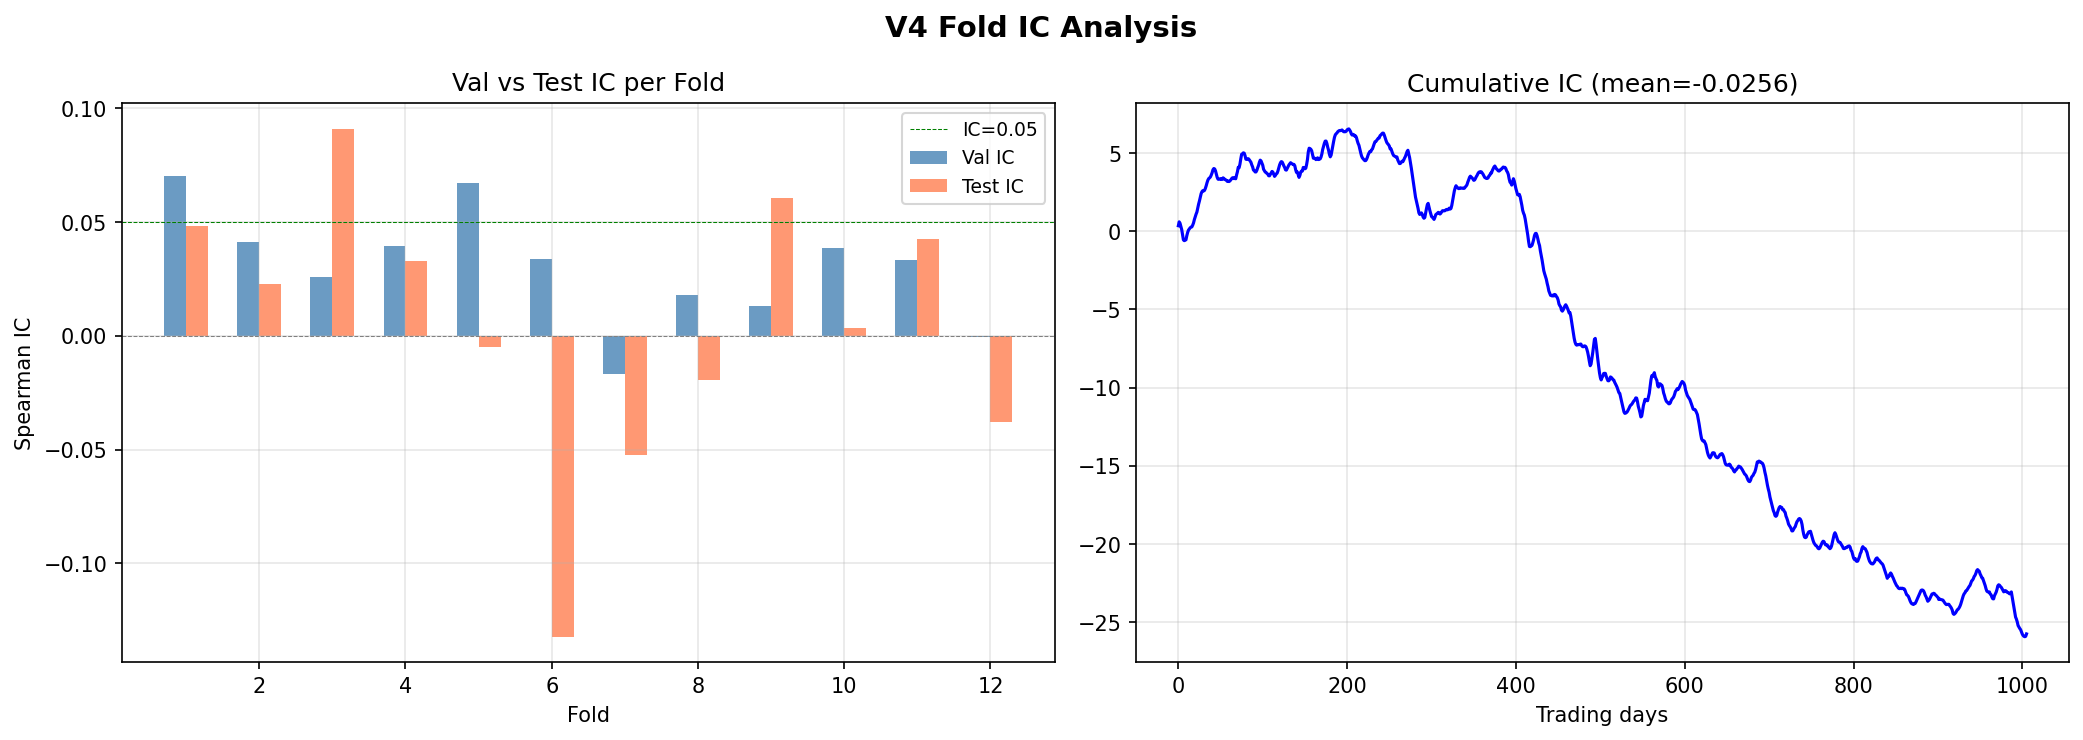

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('V4 Fold IC Analysis', fontsize=14, fontweight='bold')

ax = axes[0]
x = range(1, len(fold_metrics) + 1)
ax.bar([i-0.15 for i in x], metrics_df['val_ic'], width=0.3, color='steelblue', label='Val IC', alpha=0.8)
ax.bar([i+0.15 for i in x], metrics_df['test_ic'], width=0.3, color='coral', label='Test IC', alpha=0.8)
ax.axhline(y=0, color='gray', ls='--', lw=0.5)
ax.axhline(y=0.05, color='green', ls='--', lw=0.5, label='IC=0.05')
ax.set_xlabel('Fold'); ax.set_ylabel('Spearman IC')
ax.set_title('Val vs Test IC per Fold'); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

ax = axes[1]
dic = []
for dt, g in res_final.groupby('date'):
    if len(g) < 5: continue
    ic, _ = stats.spearmanr(g['predicted'], g['actual'])
    if not np.isnan(ic): dic.append(ic)
ax.plot(np.cumsum(dic), 'b-', lw=1.5)
ax.set_title(f'Cumulative IC (mean={np.mean(dic):.4f})'); ax.set_xlabel('Trading days'); ax.grid(True, alpha=0.3)

plt.tight_layout()
save_fig('V4_fold_ic')
plt.savefig('v4_fold_ic.png', dpi=150)  # 也存一份到项目根目录
plt.close(fig)  # 关闭 figure 防止 Jupyter 重复渲染
display(IPImage(filename=os.path.join(IMG_DIR, f'{_img_counter[0]:02d}_V4_fold_ic.png')))  # 在 cell 里显示

## 7. 回测

In [21]:
TX_COST = 0.001
REBAL_FREQ = 5
TOP_N = 3

def backtest_from_predictions(res, top_n=TOP_N, tx=TX_COST, rf=REBAL_FREQ, rev=False):
    res = res.copy()
    if rev: res['predicted'] = -res['predicted']
    dg = res.groupby('date'); rd = sorted(res['date'].unique())[::rf]
    rows, pl, ps = [], set(), set()
    for dt in rd:
        if dt not in dg.groups: continue
        g = dg.get_group(dt)
        if len(g) < 2 * top_n: continue
        g = g.sort_values('predicted', ascending=False)
        lt = set(g.head(top_n)['ticker']); st = set(g.tail(top_n)['ticker'])
        lr = g.head(top_n)['actual'].mean(); sr = -g.tail(top_n)['actual'].mean()
        to = (len(lt-pl)+len(st-ps))/(2*top_n); cost = to*tx*2; gross = (lr+sr)/2
        rows.append({'date':dt,'long_return':lr,'short_return':sr,'gross_return':gross,'net_return':gross-cost,'turnover':to,'cost':cost})
        pl, ps = lt, st
    return pd.DataFrame(rows).sort_values('date').reset_index(drop=True)

print('Signal direction test...')
for rev, lab in [(False,'Original'),(True,'Reversed')]:
    bt = backtest_from_predictions(res_final, rev=rev); r = bt['net_return']
    cum = (1+r).cumprod(); tot = cum.iloc[-1]-1; ppy = 252/REBAL_FREQ
    ar = (1+tot)**(ppy/len(r))-1; av = r.std()*np.sqrt(ppy); sh = (ar-0.04)/av if av>0 else 0
    print(f'  [{lab}] Net:{tot:.2%} | Ann:{ar:.2%} | Sharpe:{sh:.2f}')

bt_o = backtest_from_predictions(res_final, rev=False)
bt_r = backtest_from_predictions(res_final, rev=True)
use_rev = (1+bt_r['net_return']).cumprod().iloc[-1] > (1+bt_o['net_return']).cumprod().iloc[-1]
bt_final = bt_r if use_rev else bt_o
res_plot = res_final.copy()
if use_rev: res_plot['predicted'] = -res_plot['predicted']
print(f'Using {"reversed" if use_rev else "original"} signal | Trades: {len(bt_final)}')

## 8. 评估

In [22]:
def evaluate(bt, rf=REBAL_FREQ):
    ppy = 252/rf
    for lab, col in [('Gross','gross_return'),('Net','net_return')]:
        r = bt[col]; cum = (1+r).cumprod(); tot = cum.iloc[-1]-1; n = len(r)
        ar = (1+tot)**(ppy/n)-1; av = r.std()*np.sqrt(ppy)
        sh = (ar-0.04)/av if av>0 else 0; md = ((cum-cum.cummax())/cum.cummax()).min(); wr = (r>0).mean()
        print(f'\n  {"="*45}\n  {lab}\n  {"="*45}')
        print(f'    Total:  {tot:.2%}\n    Annual: {ar:.2%}\n    Vol:    {av:.2%}\n    Sharpe: {sh:.2f}\n    MaxDD:  {md:.2%}\n    WinRate:{wr:.0%}')
    print(f'\n  {"="*45}\n  By Year\n  {"="*45}')
    bc = bt.copy(); bc['year'] = pd.to_datetime(bc['date']).dt.year
    for year, grp in bc.groupby('year'):
        yr = grp['net_return']; yr_tot = (1+yr).cumprod().iloc[-1]-1
        yr_sh = (yr.mean()/yr.std()*np.sqrt(ppy)) if yr.std()>0 else 0
        print(f'    {year}: Ret={yr_tot:.2%} Sharpe={yr_sh:.2f} N={len(yr)}')

evaluate(bt_final)

## 9. 可视化

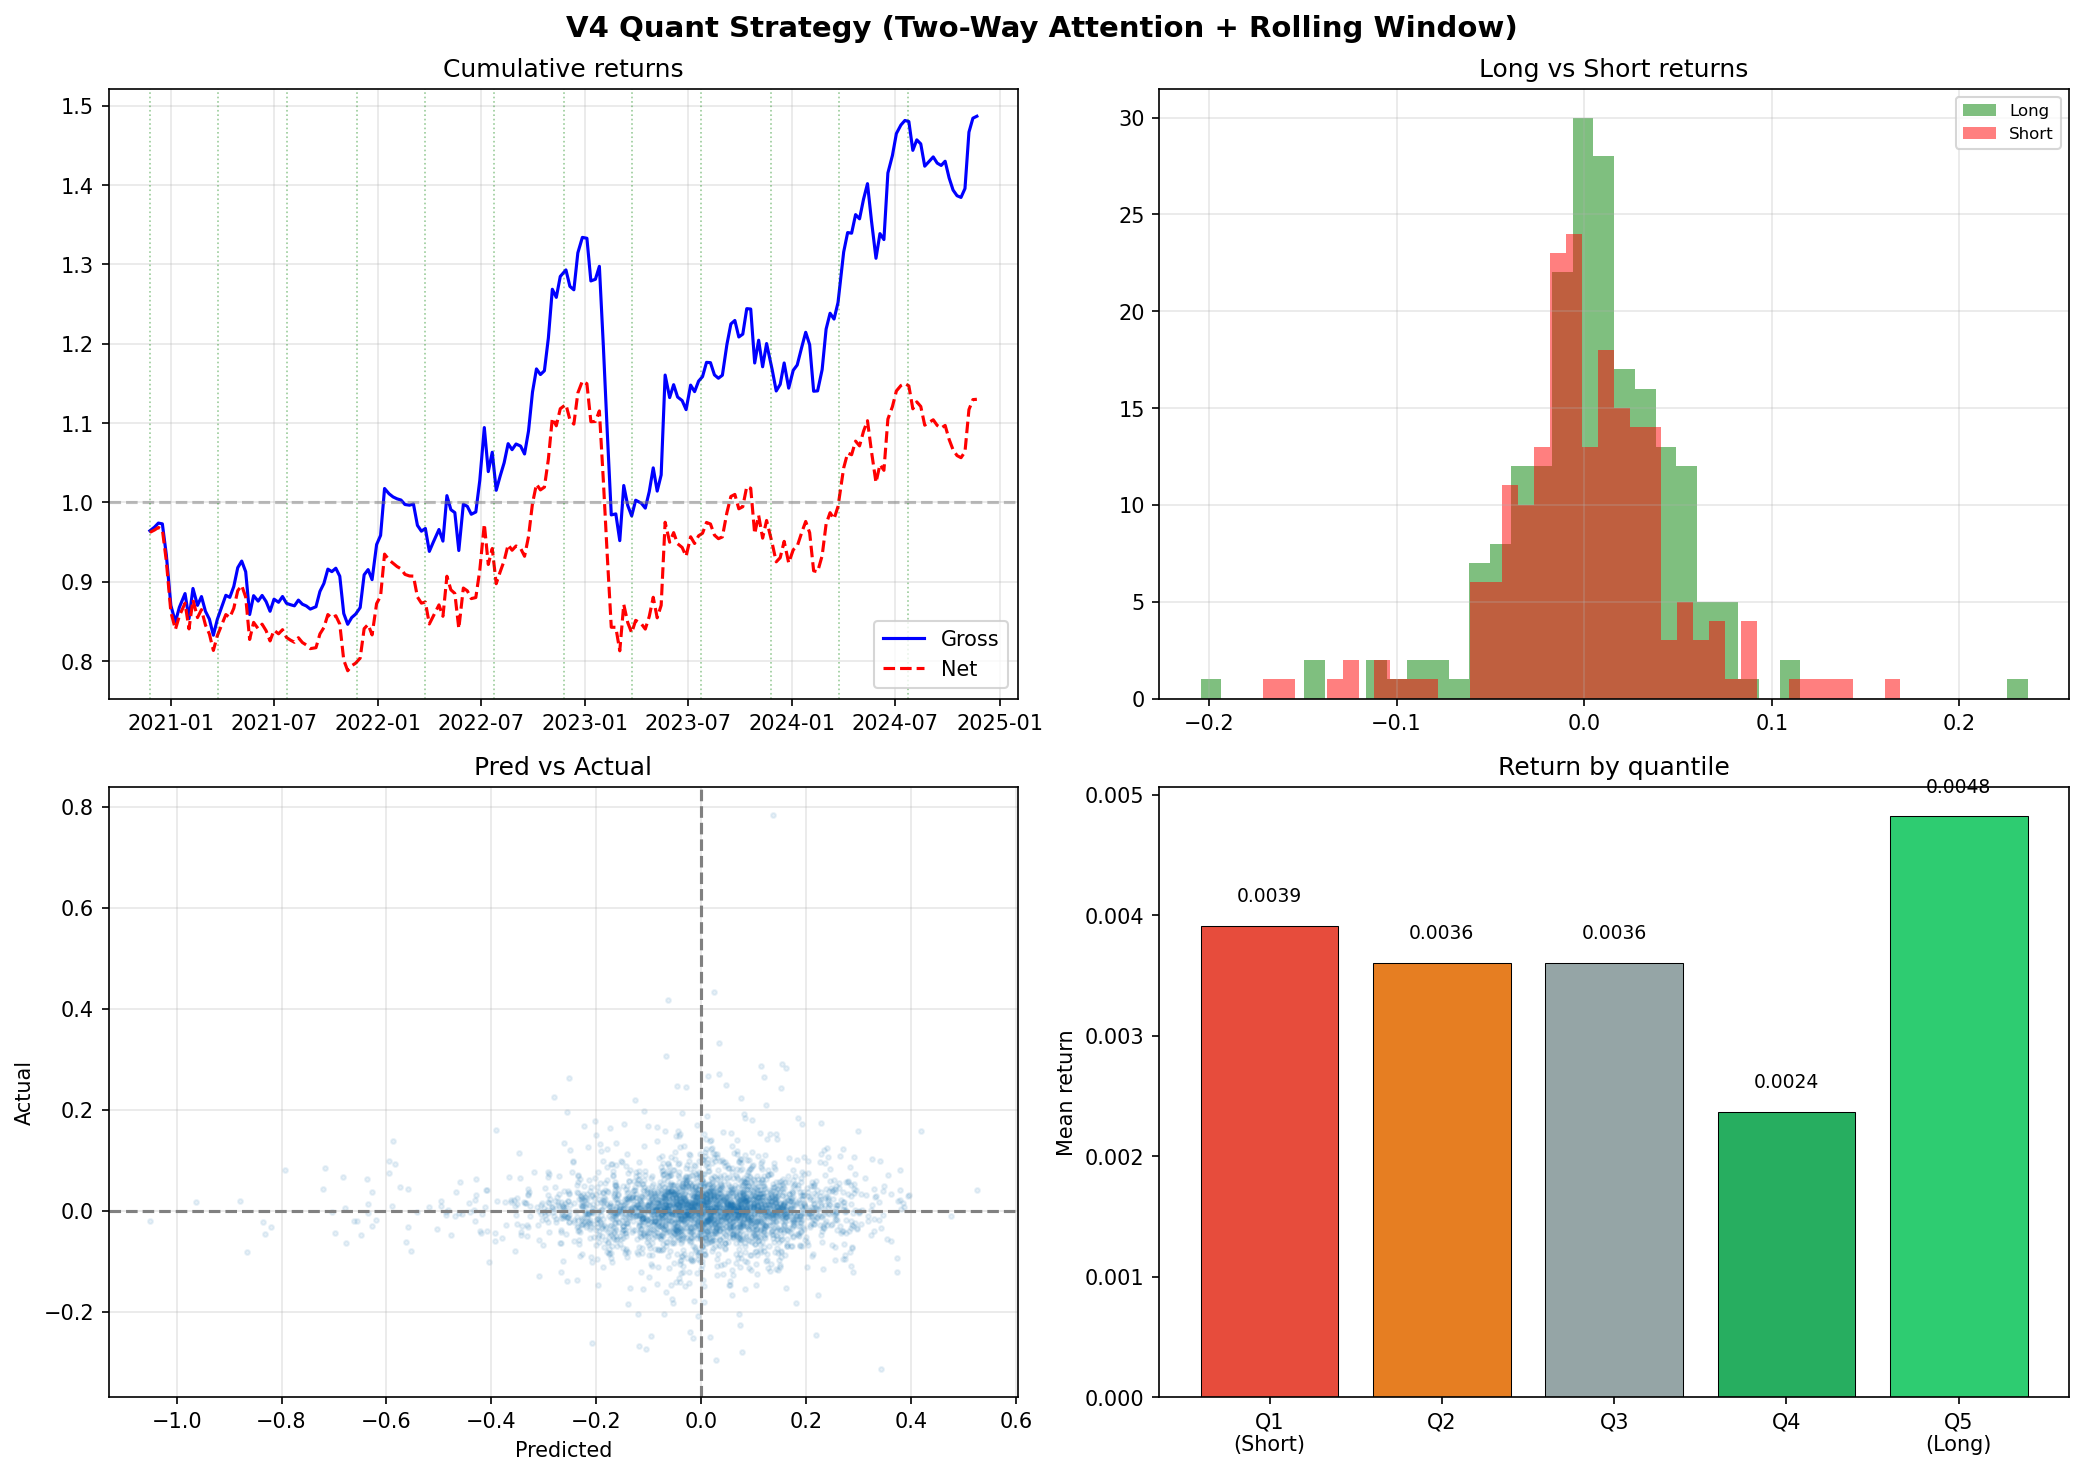

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('V4 Quant Strategy (Two-Way Attention + Rolling Window)', fontsize=14, fontweight='bold')

ax = axes[0,0]
ax.plot(bt_final['date'], (1+bt_final['gross_return']).cumprod(), 'b-', label='Gross', lw=1.5)
ax.plot(bt_final['date'], (1+bt_final['net_return']).cumprod(), 'r--', label='Net', lw=1.5)
ax.axhline(y=1, color='gray', ls='--', alpha=0.5)
for fm in fold_metrics: ax.axvline(x=fm['test_start'], color='green', ls=':', alpha=0.4, lw=0.8)
ax.legend(); ax.set_title('Cumulative returns'); ax.grid(True, alpha=0.3)

ax = axes[0,1]
ax.hist(bt_final['long_return'], bins=40, alpha=0.5, color='green', label='Long')
ax.hist(bt_final['short_return'], bins=40, alpha=0.5, color='red', label='Short')
ax.legend(fontsize=8); ax.set_title('Long vs Short returns'); ax.grid(True, alpha=0.3)

ax = axes[1,0]
s = res_plot.sample(min(3000, len(res_plot)))
ax.scatter(s['predicted'], s['actual'], alpha=0.1, s=5)
ax.axhline(y=0, color='gray', ls='--'); ax.axvline(x=0, color='gray', ls='--')
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual'); ax.set_title('Pred vs Actual'); ax.grid(True, alpha=0.3)

ax = axes[1,1]
res_plot['q'] = pd.qcut(res_plot['predicted'], q=5, labels=['Q1\n(Short)','Q2','Q3','Q4','Q5\n(Long)'])
qr = res_plot.groupby('q')['actual'].mean()
bars = ax.bar(qr.index, qr.values, color=['#e74c3c','#e67e22','#95a5a6','#27ae60','#2ecc71'], edgecolor='k', lw=0.5)
ax.axhline(y=0, color='k', ls='--', lw=0.5)
for b, v in zip(bars, qr.values): ax.text(b.get_x()+b.get_width()/2, v+0.0002, f'{v:.4f}', ha='center', fontsize=9)
ax.set_title('Return by quantile'); ax.set_ylabel('Mean return')

plt.tight_layout()
save_fig('V4_strategy_results')
plt.close(fig)
display(IPImage(filename=os.path.join(IMG_DIR, f'{_img_counter[0]:02d}_V4_strategy_results.png')))

## 10. IC 分析

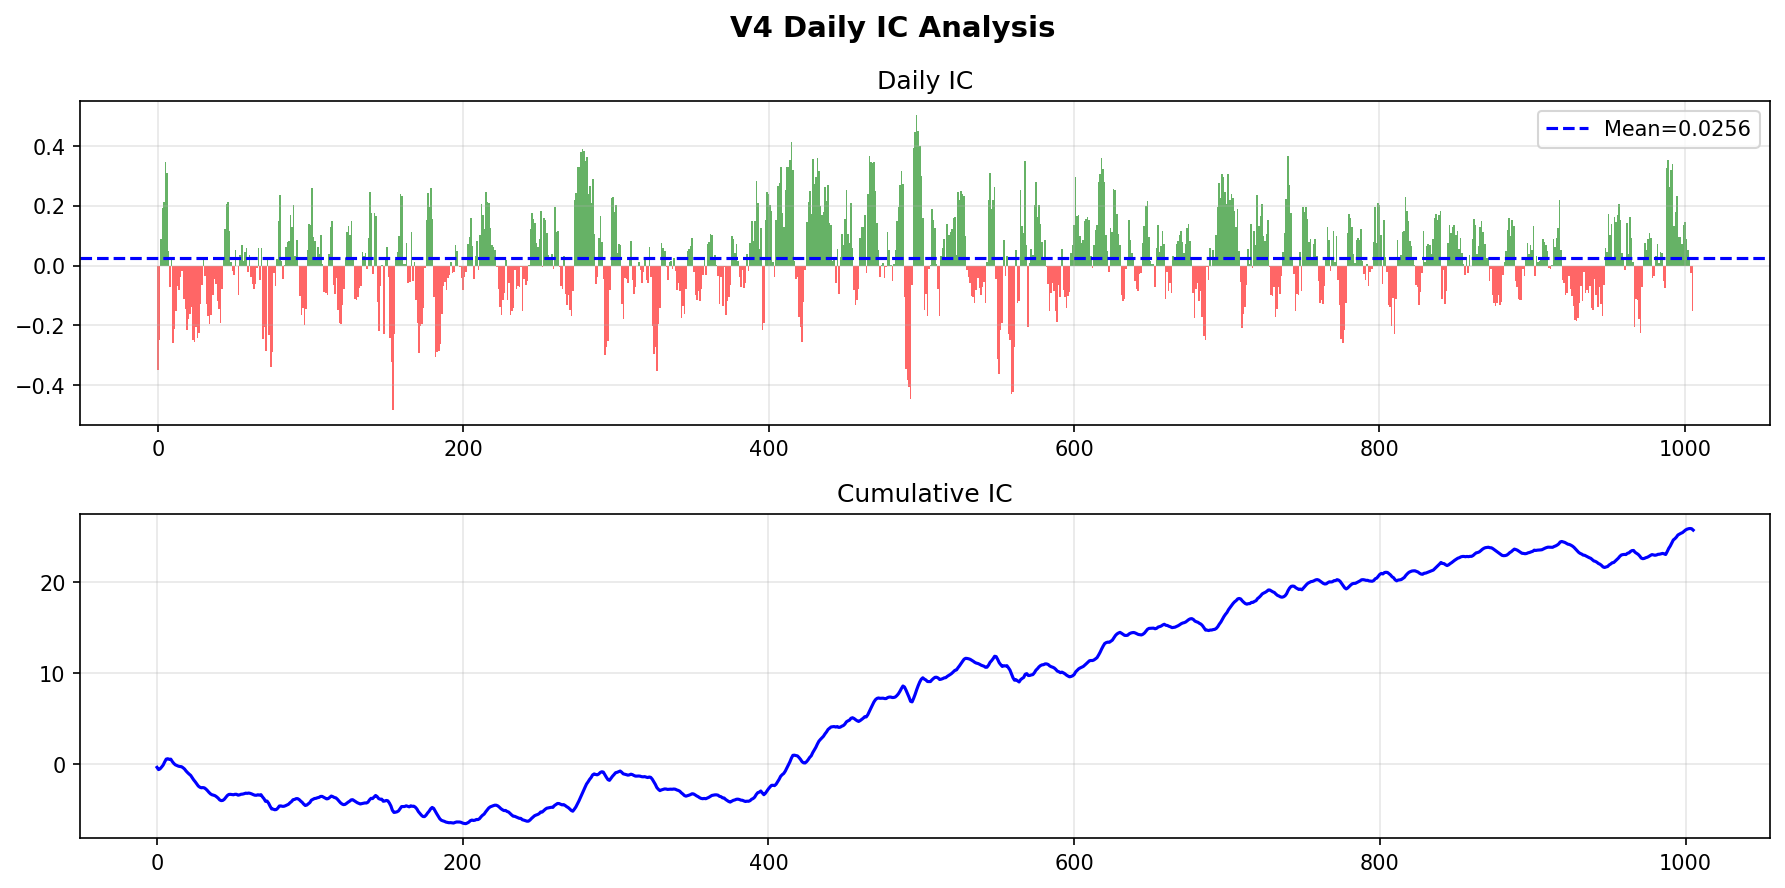

In [24]:
daily_ic = []
for dt, g in res_plot.groupby('date'):
    if len(g) < 5: continue
    ic, _ = stats.spearmanr(g['predicted'], g['actual'])
    if not np.isnan(ic): daily_ic.append({'date': dt, 'ic': ic})

idf = pd.DataFrame(daily_ic).sort_values('date')
mic, sic = idf['ic'].mean(), idf['ic'].std()
ir = mic/sic if sic>0 else 0
print(f'Mean IC: {mic:.4f} | Std: {sic:.4f} | IR: {ir:.4f} | IC>0: {(idf["ic"]>0).mean():.0%}')

fig, axes = plt.subplots(2, 1, figsize=(12, 6))
fig.suptitle('V4 Daily IC Analysis', fontsize=14, fontweight='bold')
ax = axes[0]
ax.bar(range(len(idf)), idf['ic'], color=['g' if x>0 else 'r' for x in idf['ic']], alpha=0.6, width=1)
ax.axhline(y=mic, color='blue', ls='--', label=f'Mean={mic:.4f}'); ax.legend()
ax.set_title('Daily IC'); ax.grid(True, alpha=0.3)
ax = axes[1]
ax.plot(idf['ic'].cumsum().values, 'b-', lw=1.5)
ax.set_title('Cumulative IC'); ax.grid(True, alpha=0.3)

plt.tight_layout()
save_fig('V4_daily_ic')
plt.close(fig)
display(IPImage(filename=os.path.join(IMG_DIR, f'{_img_counter[0]:02d}_V4_daily_ic.png')))

## 10.5 单股预测

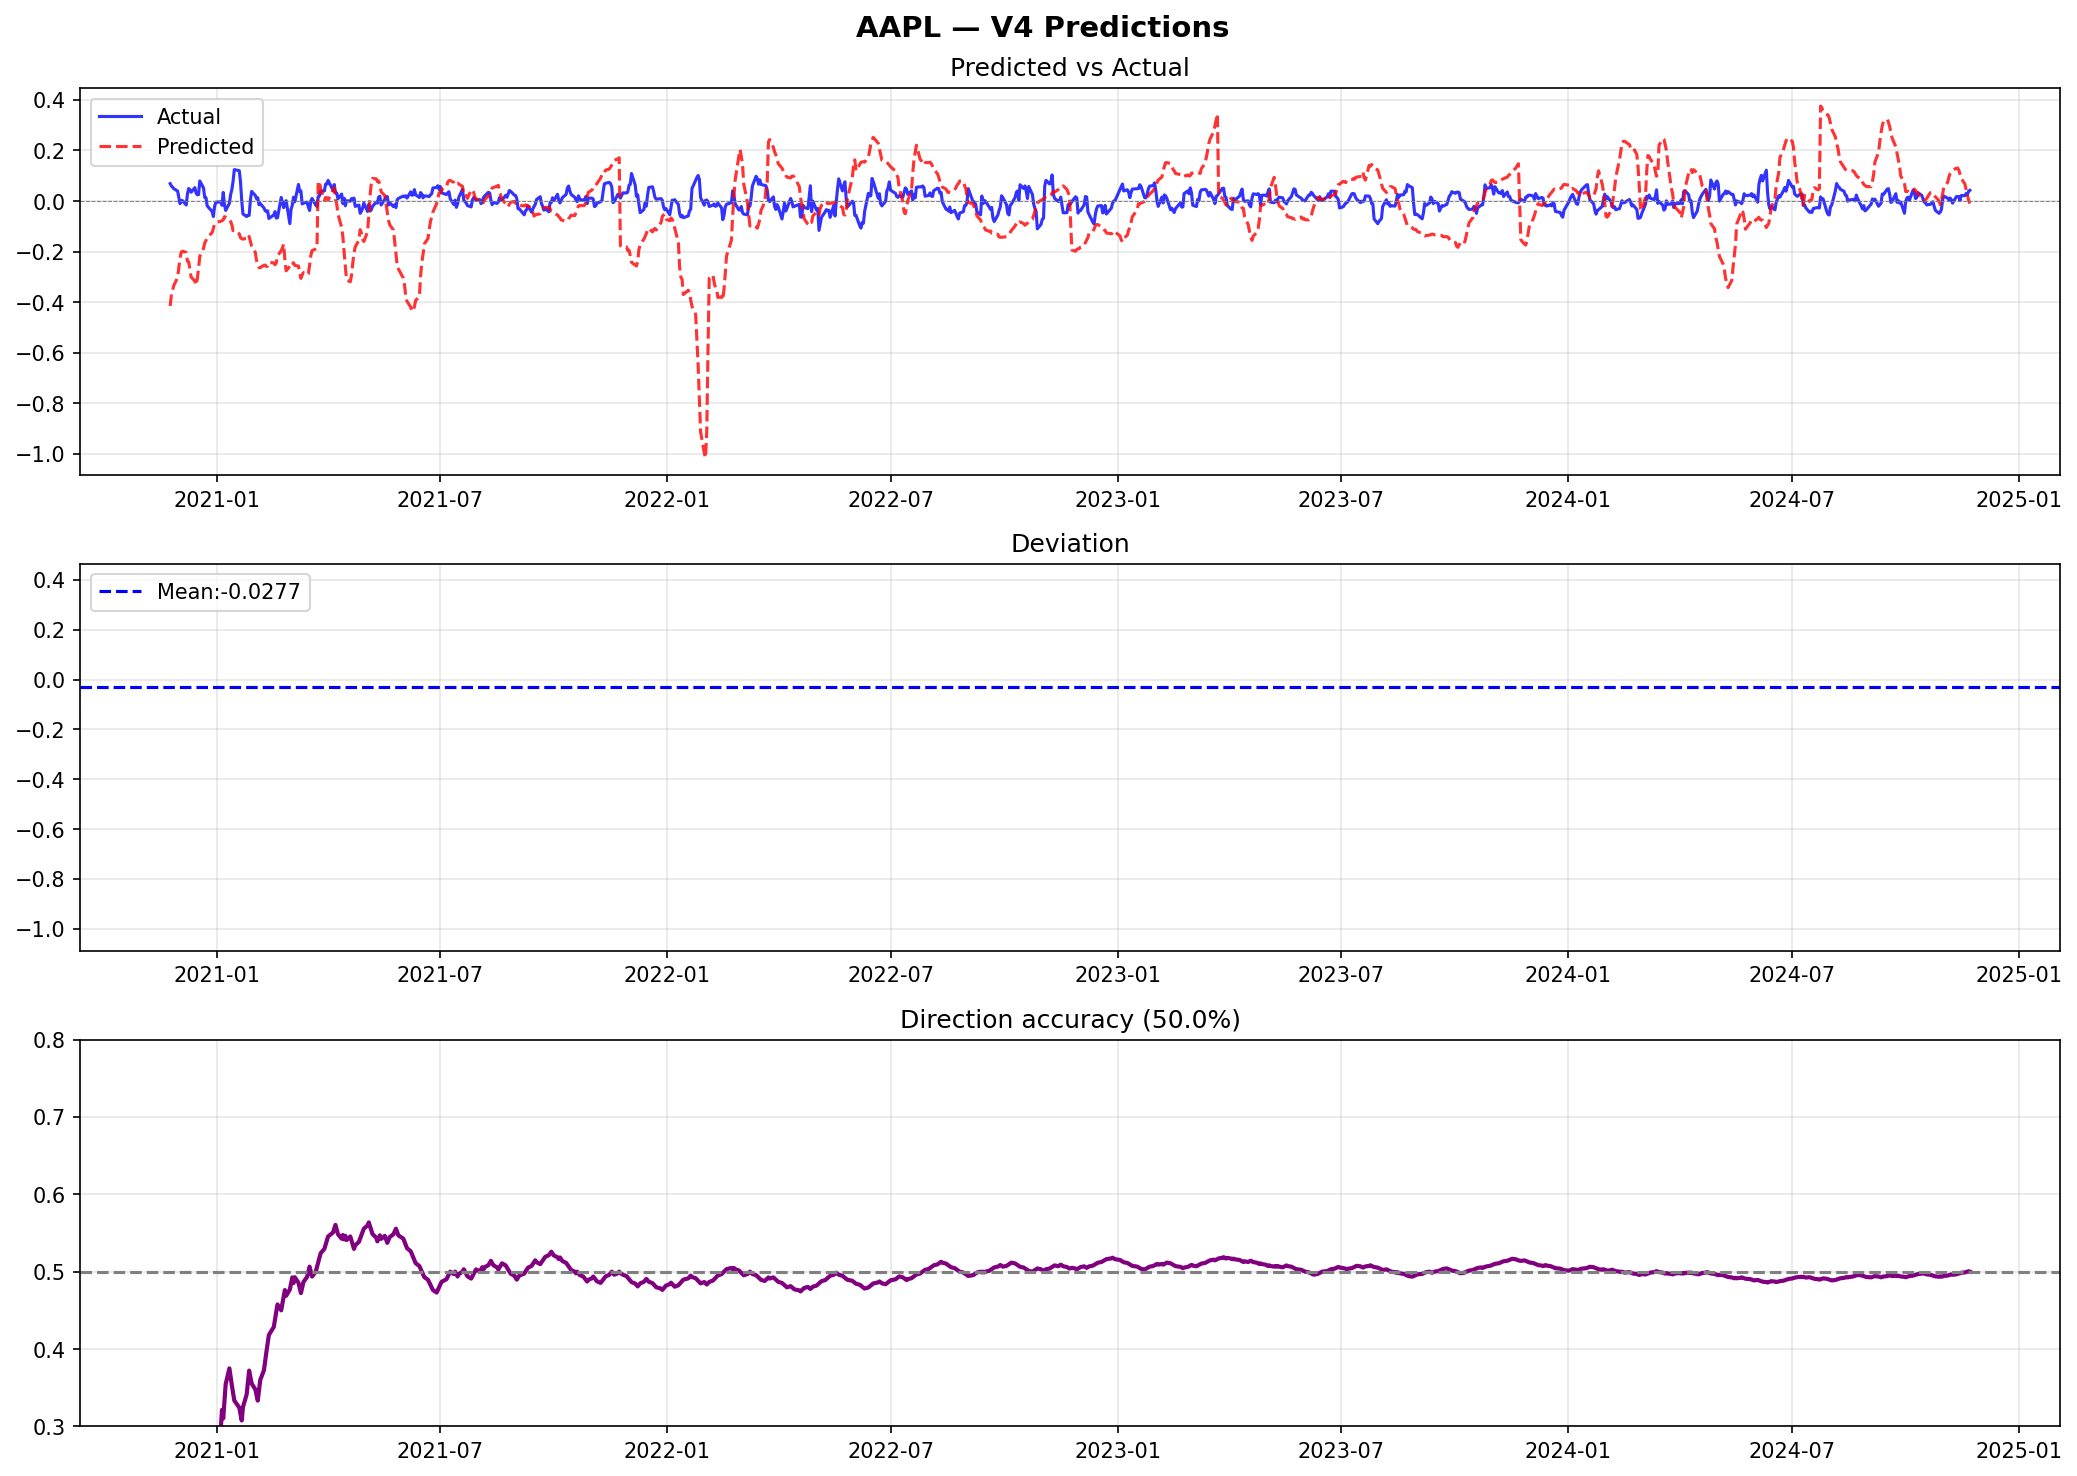

In [25]:
def plot_stock_prediction_rolling(ticker, res_plot):
    mask = res_plot[res_plot['ticker']==ticker].copy()
    if len(mask)==0: print(f'{ticker} not found'); return
    mask = mask.sort_values('date')
    dates, actuals, preds = mask['date'].values, mask['actual'].values, mask['predicted'].values

    fig, axes = plt.subplots(3, 1, figsize=(14, 10))
    fig.suptitle(f'{ticker} — V4 Predictions', fontsize=14, fontweight='bold')

    ax = axes[0]
    ax.plot(dates, actuals, 'b-', label='Actual', alpha=0.8, lw=1.5)
    ax.plot(dates, preds, 'r--', label='Predicted', alpha=0.8, lw=1.5)
    ax.axhline(y=0, color='gray', ls='--', lw=0.5)
    ax.legend(); ax.set_title('Predicted vs Actual'); ax.grid(True, alpha=0.3)

    ax = axes[1]
    dev = preds - actuals
    ax.bar(dates, dev, color=['green' if d>=0 else 'red' for d in dev], alpha=0.6, width=2)
    ax.axhline(y=dev.mean(), color='blue', ls='--', label=f'Mean:{dev.mean():.4f}')
    ax.legend(); ax.set_title('Deviation'); ax.grid(True, alpha=0.3)

    ax = axes[2]
    correct = (np.sign(preds)==np.sign(actuals)).astype(int)
    ax.plot(dates, pd.Series(correct).expanding().mean(), 'purple', lw=2)
    ax.axhline(y=0.5, color='gray', ls='--'); ax.set_ylim(0.3, 0.8)
    ax.set_title(f'Direction accuracy ({correct.mean():.1%})'); ax.grid(True, alpha=0.3)

    plt.tight_layout()
    save_fig(f'{ticker}_V4')
    plt.close(fig)
    display(IPImage(filename=os.path.join(IMG_DIR, f'{_img_counter[0]:02d}_{ticker}_V4.png')))

    corr = np.corrcoef(preds, actuals)[0,1]
    print(f'{ticker}: {len(mask)} samples | Dir acc: {correct.mean():.1%} | Corr: {corr:.4f}')

plot_stock_prediction_rolling('AAPL', res_plot)

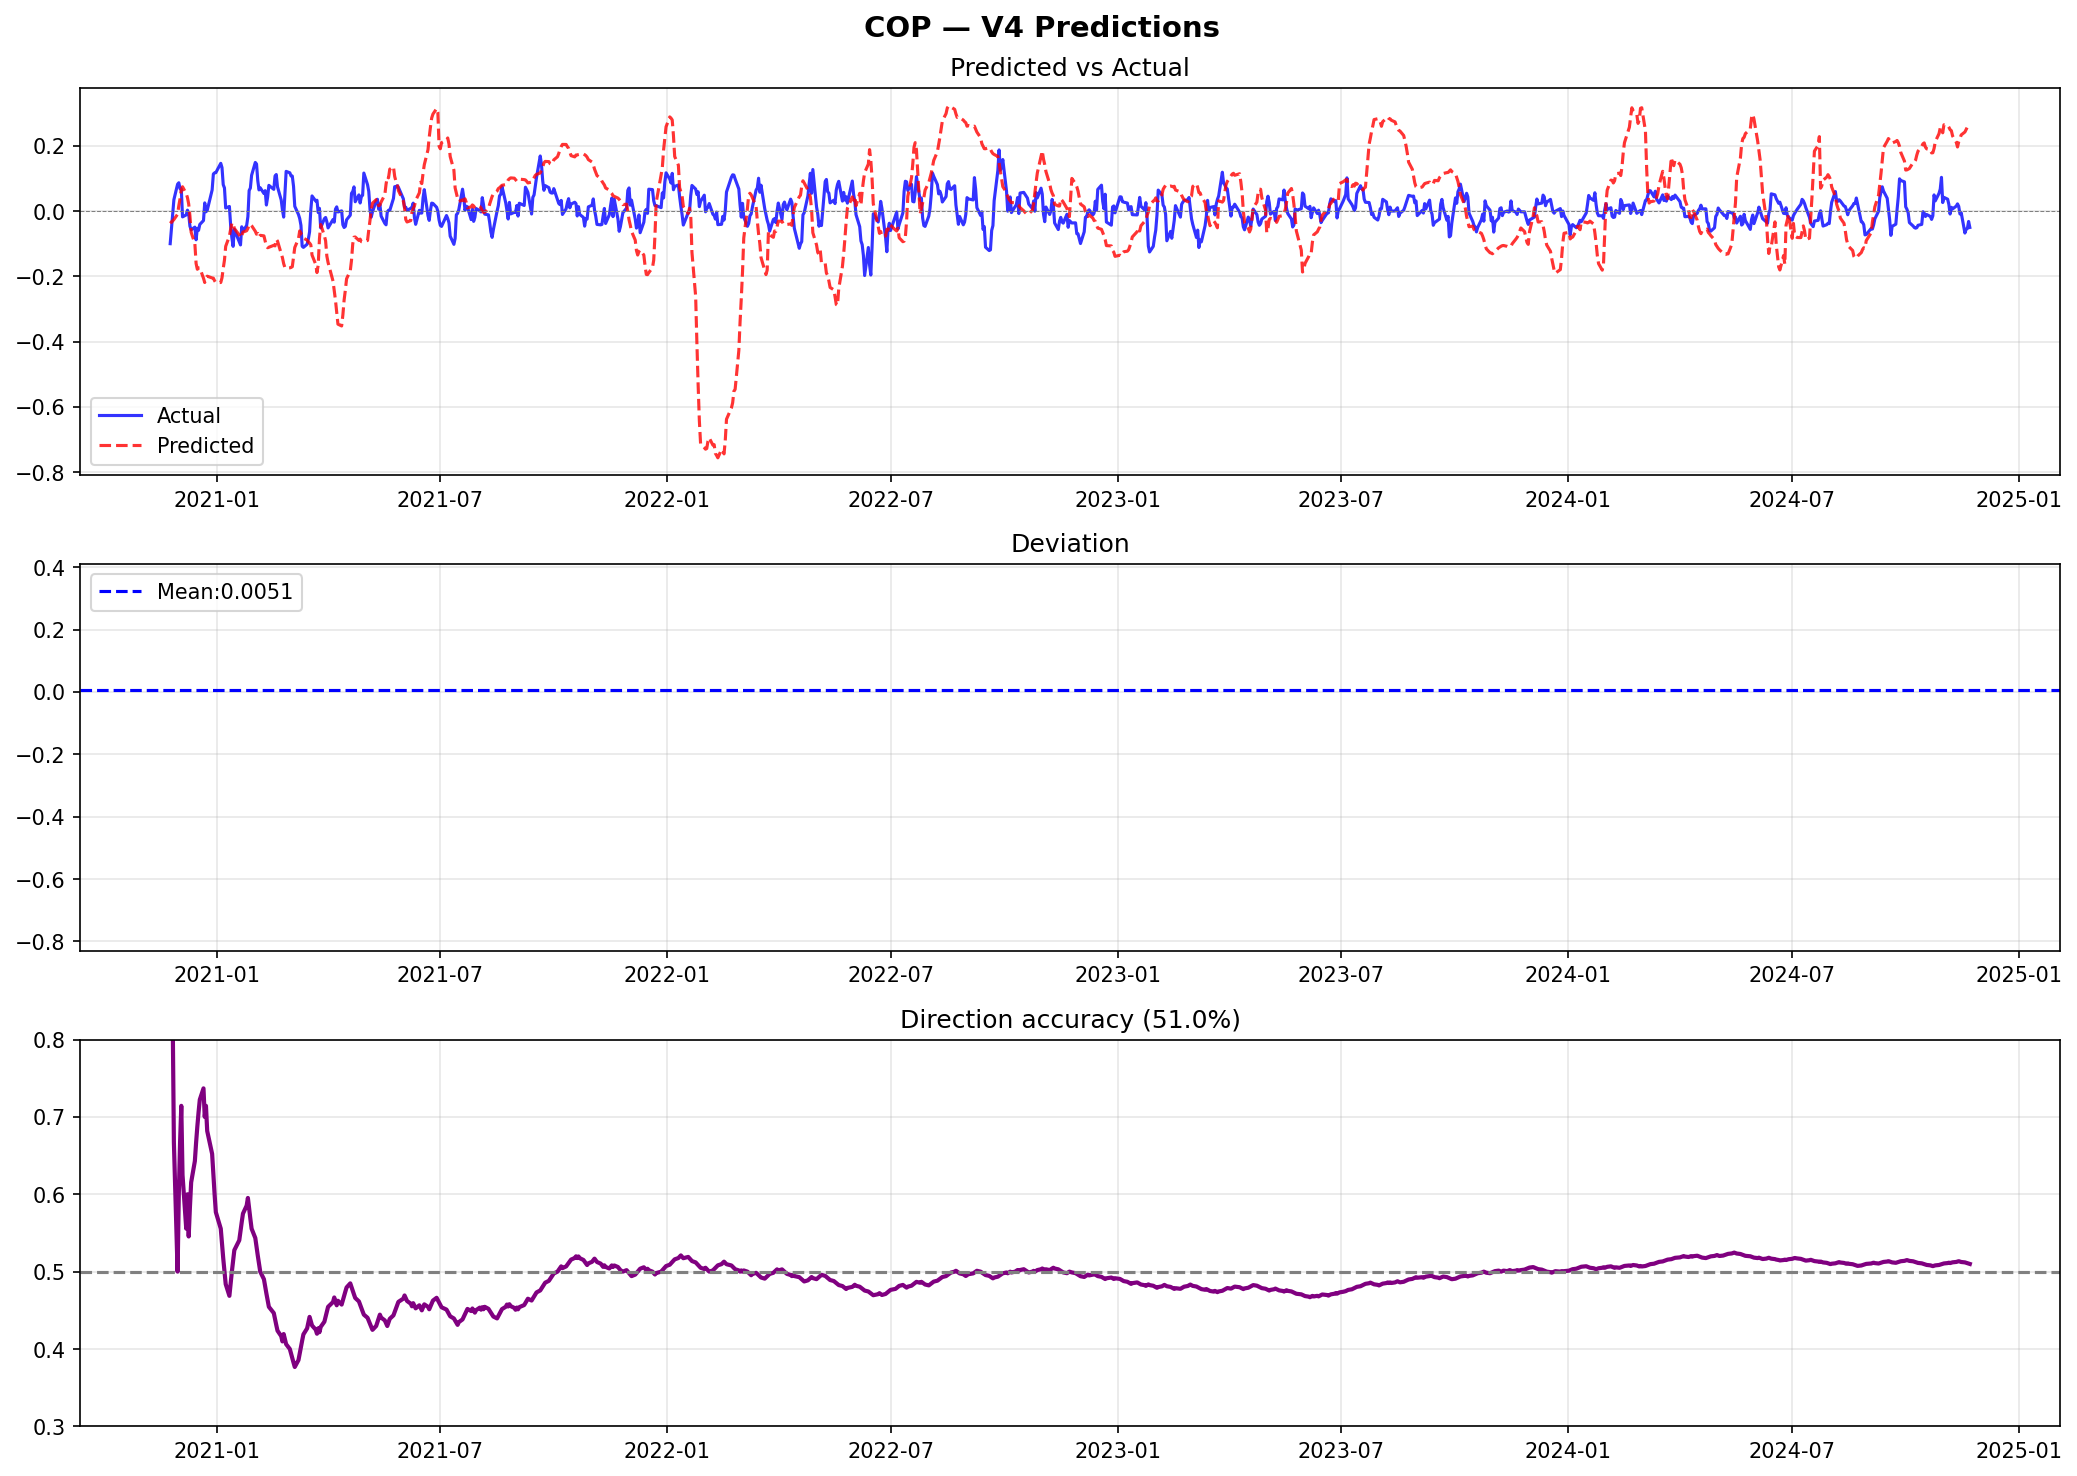

In [26]:
plot_stock_prediction_rolling('COP', res_plot)

## 11. 可调参数

| 参数 | 位置 | 当前值 | 建议范围 |
|------|------|--------|----------|
| `d_model` | Cell 4 | 128 | 64 / 256 |
| `num_layers` | Cell 4 | 3 | 2 / 4 |
| `nhead` | Cell 4 | 4 | 2 / 8 |
| `dropout` | Cell 4 | 0.15 | 0.1 / 0.25 |
| `listnet_weight` | Cell 5 | 0.7 | 0.5 / 0.9 |
| `temperature` | Cell 5 | 1.0 | 0.5 / 2.0 |
| `num_epochs` | Cell 6 | 60 | 40 / 100 |
| `patience` | Cell 6 | 8 | 5 / 15 |
| `lr` | Cell 6 | 3e-4 | 1e-4 / 5e-4 |
| `TOP_N` | Cell 7 | 3 | 2 / 5 / 10 |
| `REBAL_FREQ` | Cell 7 | 5 | 3 / 10 |
| `BATCH_DAYS` | Cell 7 | 8 | 16 / 32 |

BATCH_DAYS(减少循环，多少个日期进入GPU)